In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def getMean(nums, n):
    totalSum = 0
    for i in range(n):
        totalSum += nums[i]

    return totalSum/n

In [5]:
def calculateSquareLoss(x, y, w0, w1, n):
    total_loss = 0
    for i in range(n):
        total_loss += (y[i] - w1*x[i] - w0)**2

    return total_loss

In [6]:
def updateSlope(x_bar, y_bar, Xi_s, Yi_s, n):
    numerator = 0
    denominator = 0

    for i in range(n):
        numerator += (Xi_s[i] - x_bar) * (Yi_s[i] - y_bar)
        denominator += (Xi_s[i] - x_bar) ** 2

    w1 = numerator / denominator
    return w1

In [7]:
def updateBias(w1, x_bar, y_bar):
    return y_bar - w1*x_bar

#### Ordinary Least Squares (OLS)
Unlike Gradient Descent, which takes many small steps to "find" the best weights, OLS uses calculus and algebra to calculate the exact optimal weights in one go

In [8]:
def ols(x, y, w0, w1, n):
    x_bar = getMean(x, n)
    y_bar = getMean(y, n)
    print(calculateSquareLoss(x, y, w0, w1, n))
    w1 = updateSlope(x_bar, y_bar, x, y, n)
    w0 = updateBias(w1, x_bar, y_bar)
    return [w0, w1]


#### Gradient Descent
 In every iteration of the optimization process, we update the weights $w_0$ and $w_1$ simultaneously using the following rules:$$w_0 = w_0 - \eta \frac{\partial L}{\partial w_0}$$$$w_1 = w_1 - \eta \frac{\partial L}{\partial w_1}$$Partial Derivatives (Gradients)The gradients for the loss function $L$ with respect to each weight are calculated as:$$\frac{\partial L}{\partial w_0} = \frac{2}{n}\sum_{i=1}^{n} (y_{pred} - y)$$$$\frac{\partial L}{\partial w_1} = \frac{2}{n}\sum_{i=1}^{n} (y_{pred} - y)x$$

In [9]:
def trainViaGradientDescent(x, y, lr=0.001, iterations=1000):
    w0 = 0
    w1 = 0
    n = len(x)
    w0_history = []
    w1_history = []

    for i in range(iterations):
        dw0 = 0
        dw1 = 0
        for j in range(n):
            y_pred = w1 * x[j] + w0
            error = y_pred - y[j]

            dw0 += error
            dw1 += error * x[j]

        dw0 = (2/n) * dw0
        dw1 = (2/n) * dw1

        w0 = w0 - lr * dw0
        w1 = w1 - lr * dw1

        w0_history.append(w0)
        w1_history.append(w1)

    return w0, w1, w0_history, w1_history

In [10]:
def plotLossSurface(x, y, w0_hist, w1_hist):
    w0_vals = np.linspace(-10, 10, 100)
    w1_vals = np.linspace(-10, 10, 100)

    W0, W1 = np.meshgrid(w0_vals, w1_vals)
    Loss = np.zeros_like(W0)

    for i in range(len(w0_vals)):
        for j in range(len(w1_vals)):
            Loss[i,j] = calculateSquareLoss(x, y, W0[i,j], W1[i,j], len(x))

    plt.contour(W0, W1, Loss, levels=50)

    # plot gradient descent path
    plt.plot(w0_hist, w1_hist, 'ro-')

    plt.xlabel("w0 (bias)")
    plt.ylabel("w1 (slope)")
    plt.title("Loss Surface and Gradient Descent Path")
    plt.show()

In [11]:
def predict(m, b):
    x = float(input("Input the value x: "))
    ans = m*x + b
    print("the predicted value y is {}".format(ans))

OLS
Loss before OLS: 235
235
Loss after OLS:  1.1814946619217088
OLS weights -> w0 (bias): 0.3915, w1 (slope): 1.0569

Gradient Descent
GD weights  -> w0 (bias): 0.2560, w1 (slope): 1.0781
Loss after GD:  1.209055399908725


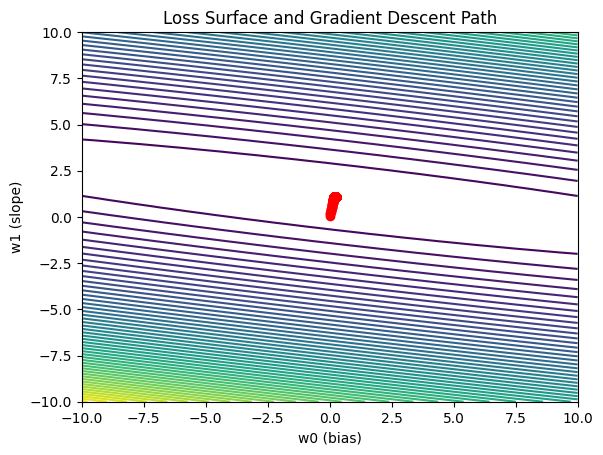


Predict (using Gradient Descent weights)
the predicted value y is 5.646572434484748


In [12]:
def main():
    x = [1, 2, 4, 6, 7, 9]
    y = [1, 3, 5, 6, 8, 10]
    n = len(x)

    # OLS
    print("\033[31m" + "OLS" + "\033[0m")
    print("Loss before OLS:", calculateSquareLoss(x, y, 0, 0, n))
    w_ols = ols(x, y, 0, 0, n)
    print("Loss after OLS: ", calculateSquareLoss(x, y, w_ols[0], w_ols[1], n))
    print(f"OLS weights -> w0 (bias): {w_ols[0]:.4f}, w1 (slope): {w_ols[1]:.4f}")

    # Gradient Descent
    print("\n\033[31m" + "Gradient Descent" + "\033[0m")
    w0, w1, w0_hist, w1_hist = trainViaGradientDescent(x, y)
    print(f"GD weights  -> w0 (bias): {w0:.4f}, w1 (slope): {w1:.4f}")
    print("Loss after GD: ", calculateSquareLoss(x, y, w0, w1, n))

    # Plot
    plotLossSurface(x, y, w0_hist, w1_hist)

    # Predict
    print("\n\033[31m" + "Predict (using Gradient Descent weights)" + "\033[0m")
    predict(w1, w0)

main()